# Отчет по лабораторной работе №2: Исследование методов анализа ассоциативных правил

**Дисциплина:** Системы искусственного интеллекта и машинное обучение  
**Тема:** Ассоциативные правила (Apriori, FPGrowth)  
**Вариант:** Medical Cost Personal Datasets (`insurance.csv`)

**Работу выполнил Немченко Е.В. студент гр. АП-226**

## 1. Введение

### Цель работы

Исследовать методы анализа ассоциативных правил на примере датасета медицинских расходов `Medical Cost Personal Datasets`, реализовать алгоритмы Apriori и FPGrowth, проанализировать влияние их параметров и визуализировать полученные правила.

### Постановка задачи

В рамках лабораторной работы требуется:

1. Загрузить датасет медицинских расходов и сформировать из него транзакционное представление ("корзины" признаков для каждого пациента).
2. Описать структуру данных и показать:
   - распределение длин транзакций;
   - список уникальных "товаров" (признаков/категорий), участвующих в правилах.
3. Реализовать алгоритм Apriori, получить частые наборы и ассоциативные правила, проанализировать полезные и тривиальные правила, а также метрики поддержки, достоверности и лифта.
4. Исследовать влияние параметров алгоритма (поддержка и достоверность) на количество и качество получаемых правил.
5. Реализовать алгоритм FPGrowth и сравнить набор правил с результатами Apriori.
6. Алгоритмически определить минимальные значения поддержки для составления правил длины 1, 2, 3 и более.
7. Проанализировать построенный граф ассоциативных правил.
8. Предложить и реализовать собственный способ визуализации ассоциативных правил и их метрик.

### Краткое описание используемого датасета

Датасет **Medical Cost Personal Datasets** (`insurance.csv`) содержит записи о пациентах и их индивидуальных медицинских расходах. Для каждого пациента доступны следующие признаки:

- `age` — возраст;
- `sex` — пол;
- `bmi` — индекс массы тела;
- `children` — количество детей;
- `smoker` — факт курения (да/нет);
- `region` — регион проживания;
- `charges` — годовые медицинские расходы.

В контексте анализа ассоциативных правил каждая запись (пациент) будет рассматриваться как транзакция, а отдельные категориальные/дискретизированные значения признаков — как "товары" в корзине.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
import networkx as nx

sns.set(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

# Загрузка датасета insurance
local_path = Path("../data/insurance.csv")
backup_url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

if local_path.exists():
    df = pd.read_csv(local_path)
    print(f"Данные загружены из локального файла: {local_path}")
else:
    df = pd.read_csv(backup_url)
    print("Локальный файл не найден, данные загружены по URL.")

print("Размер датасета:", df.shape)
display(df.head())

Данные загружены из локального файла: ..\data\insurance.csv
Размер датасета: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Анализ данных и формирование транзакций

В классическом анализе рыночной корзины каждая транзакция представляет собой список товаров, купленных одновременно. В данном случае в роли транзакций выступают **пациенты**, а в роли товаров — **категории признаков**, описывающие пациента (возрастные группы, категории ИМТ, наличие детей, статус курения и т.д.).

Далее будет выполнена:

- первичная статистика по исходному датасету;
- дискретизация числовых признаков на интервальные категории;
- формирование бинарной матрицы "пациент × признак" для последующего применения алгоритмов Apriori и FPGrowth;
- анализ распределения длин транзакций и множества уникальных "товаров".

In [ ]:
# Первичный анализ датасета
print("Информация о датасете:")
print(df.info())

print("\nКраткая статистика по числовым признакам:")
display(df.describe())

print("\nРаспределение по категориальным признакам:")
for col in ["sex", "smoker", "region", "children"]:
    print(f"\nСтолбец: {col}")
    display(df[col].value_counts())

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None

Краткая статистика по числовым признакам:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



Распределение по категориальным признакам:

Столбец: sex


sex
male      676
female    662
Name: count, dtype: int64


Столбец: smoker


smoker
no     1064
yes     274
Name: count, dtype: int64


Столбец: region


region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


Столбец: children


children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [ ]:
# Дискретизация числовых признаков и формирование категориальных "товаров"

# Возраст: молодые / средний возраст / пожилые
age_bins = [17, 30, 50, 65, 80]
age_labels = ["age_18_30", "age_31_50", "age_51_65", "age_66_plus"]

# BMI: нормальный, избыточный, ожирение
bmi_bins = [15, 25, 30, 35, 60]
bmi_labels = ["bmi_normal", "bmi_overweight", "bmi_obese_I", "bmi_obese_II_plus"]

# Charges: квартильное разбиение
charges_labels = ["charges_low", "charges_medium", "charges_high", "charges_very_high"]

work_df = df.copy()
work_df["age_group"] = pd.cut(work_df["age"], bins=age_bins, labels=age_labels, include_lowest=True)
work_df["bmi_group"] = pd.cut(work_df["bmi"], bins=bmi_bins, labels=bmi_labels, include_lowest=True)
work_df["children_group"] = pd.cut(work_df["children"], bins=[-1, 0, 2, 10], labels=["children_0", "children_1_2", "children_3_plus"], include_lowest=True)
work_df["charges_group"] = pd.qcut(work_df["charges"], q=4, labels=charges_labels)

cat_cols = [
    "sex",
    "smoker",
    "region",
    "age_group",
    "bmi_group",
    "children_group",
    "charges_group",
]

print("Категориальные признаки, участвующие в транзакциях:")
print(cat_cols)

display(work_df[cat_cols].head())

Категориальные признаки, участвующие в транзакциях:
['sex', 'smoker', 'region', 'age_group', 'bmi_group', 'children_group', 'charges_group']


,sex,smoker,region,age_group,bmi_group,children_group,charges_group
0,female,yes,southwest,age_18_30,bmi_overweight,children_0,charges_very_high
1,male,no,southeast,age_18_30,bmi_obese_I,children_1_2,charges_low
2,male,no,southeast,age_18_30,bmi_obese_I,children_3_plus,charges_low
3,male,no,northwest,age_31_50,bmi_normal,children_0,charges_very_high
4,male,no,northwest,age_31_50,bmi_overweight,children_0,charges_low


In [ ]:
# One-Hot Encoding для формирования бинарной матрицы транзакций

data_encoded = pd.get_dummies(work_df[cat_cols])

# Приводим к типу bool, как рекомендует mlxtend
data_encoded = data_encoded.astype(bool)

print("Размер бинарной матрицы (транзакции × товары):", data_encoded.shape)
display(data_encoded.head())

Размер бинарной матрицы (транзакции × товары): (1338, 23)


,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,age_group_age_18_30,age_group_age_31_50,age_group_age_51_65,age_group_age_66_plus,bmi_group_bmi_normal,bmi_group_bmi_overweight,bmi_group_bmi_obese_I,bmi_group_bmi_obese_II_plus,children_group_children_0,children_group_children_1_2,children_group_children_3_plus,charges_group_charges_low,charges_group_charges_medium,charges_group_charges_high,charges_group_charges_very_high
0,True,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,False,True
1,False,True,True,False,False,False,True,False,True,False,False,False,False,False,True,False,False,True,False,True,False,False,False
2,False,True,True,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,True,True,False,False,False
3,False,True,True,False,False,True,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,True
4,False,True,True,False,False,True,False,False,False,True,False,False,False,True,False,False,True,False,False,True,False,False,False


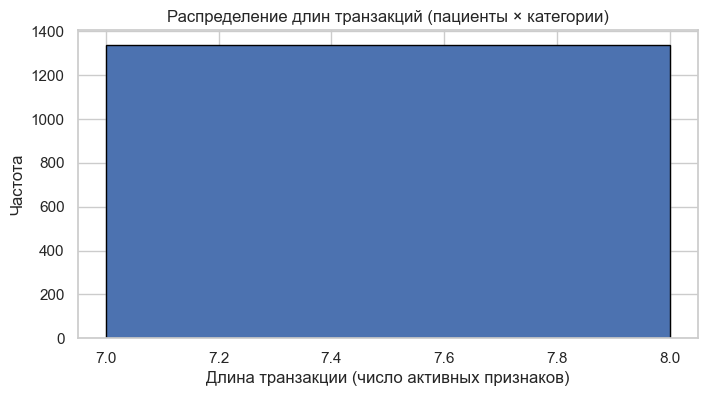

Минимальная длина транзакции: 7
Максимальная длина транзакции: 7
Средняя длина транзакции: 7.0


In [ ]:
# Распределение длин транзакций
transaction_lengths = data_encoded.sum(axis=1)

plt.figure(figsize=(8, 4))
plt.hist(transaction_lengths, bins=range(int(transaction_lengths.min()), int(transaction_lengths.max()) + 2), edgecolor="black")
plt.xlabel("Длина транзакции (число активных признаков)")
plt.ylabel("Частота")
plt.title("Распределение длин транзакций (пациенты × категории)")
plt.show()

print("Минимальная длина транзакции:", int(transaction_lengths.min()))
print("Максимальная длина транзакции:", int(transaction_lengths.max()))
print("Средняя длина транзакции:", transaction_lengths.mean().round(2))

In [ ]:
# Список уникальных "товаров" (категорий)
unique_items = list(data_encoded.columns)

print(f"Количество уникальных товаров (категорий): {len(unique_items)}")
print("Первые 15 товаров:")
print(unique_items[:15])

Количество уникальных товаров (категорий): 23
Первые 15 товаров:
['sex_female', 'sex_male', 'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest', 'age_group_age_18_30', 'age_group_age_31_50', 'age_group_age_51_65', 'age_group_age_66_plus', 'bmi_group_bmi_normal', 'bmi_group_bmi_overweight', 'bmi_group_bmi_obese_I']


## 3. Ход работы

### 3.1 Алгоритм Apriori: базовый запуск

В этом разделе выполняется поиск частых наборов признаков и построение ассоциативных правил с помощью алгоритма Apriori. В качестве начальных параметров выберем:

- минимальная поддержка `min_support = 0.05` (наблюдается не менее чем у 5% пациентов);
- минимальная достоверность `min_confidence = 0.3`.

Будут получены частые наборы, сгенерированы правила, а также выделены примеры **полезных** (существенных) и **тривиальных** правил.

In [ ]:
# Базовый запуск алгоритма Apriori

min_support_base = 0.05
min_conf_base = 0.3

frequent_itemsets = apriori(data_encoded, min_support=min_support_base, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

print("Частые наборы (первые 10):")
display(frequent_itemsets.sort_values(["support", "length"], ascending=[False, False]).head(10))

rules_apriori = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_conf_base)

# Добавим длину антецедента и консеквента
rules_apriori["antecedent_len"] = rules_apriori["antecedents"].apply(lambda x: len(x))
rules_apriori["consequent_len"] = rules_apriori["consequents"].apply(lambda x: len(x))

print("\nАссоциативные правила (первые 10):")
display(rules_apriori.head(10))

print("Количество сгенерированных правил:", len(rules_apriori))

Частые наборы (первые 10):


,support,itemsets,length
2,0.795217,frozenset({smoker_no}),1
1,0.505232,frozenset({sex_male}),1
0,0.494768,frozenset({sex_female}),1
15,0.428999,frozenset({children_group_children_0}),1
16,0.421525,frozenset({children_group_children_1_2}),1
22,0.408819,"frozenset({sex_female, smoker_no})",2
9,0.402093,frozenset({age_group_age_31_50}),1
42,0.386398,"frozenset({sex_male, smoker_no})",2
73,0.343049,"frozenset({children_group_children_0, smoker_no})",2
74,0.334828,"frozenset({smoker_no, children_group_children_...",2



Ассоциативные правила (первые 10):


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent_len,consequent_len
0,frozenset({sex_female}),frozenset({smoker_no}),0.494768,0.795217,0.408819,0.826284,1.039068,1.0,0.015371,1.178839,0.074419,0.463953,0.151708,0.670191,1,1
1,frozenset({smoker_no}),frozenset({sex_female}),0.795217,0.494768,0.408819,0.514098,1.039068,1.0,0.015371,1.039780,0.183603,0.463953,0.038259,0.670191,1,1
2,frozenset({smoker_yes}),frozenset({sex_female}),0.204783,0.494768,0.085949,0.419708,0.848292,1.0,-0.015371,0.870651,-0.183603,0.140073,-0.148566,0.296712,1,1
3,frozenset({region_northeast}),frozenset({sex_female}),0.242152,0.494768,0.120329,0.496914,1.004336,1.0,0.000519,1.004264,0.005697,0.195152,0.004246,0.370058,1,1
4,frozenset({region_northwest}),frozenset({sex_female}),0.242900,0.494768,0.122571,0.504615,1.019902,1.0,0.002392,1.019878,0.025775,0.199271,0.019490,0.376175,1,1
5,frozenset({region_southeast}),frozenset({sex_female}),0.272048,0.494768,0.130792,0.480769,0.971706,1.0,-0.003808,0.973039,-0.038462,0.205640,-0.027708,0.372560,1,1
6,frozenset({region_southwest}),frozenset({sex_female}),0.242900,0.494768,0.121076,0.498462,1.007465,1.0,0.000897,1.007364,0.009786,0.196364,0.007310,0.371587,1,1
7,frozenset({sex_female}),frozenset({age_group_age_18_30}),0.494768,0.331839,0.159940,0.323263,0.974157,1.0,-0.004243,0.987328,-0.049888,0.239910,-0.012835,0.402622,1,1
8,frozenset({age_group_age_18_30}),frozenset({sex_female}),0.331839,0.494768,0.159940,0.481982,0.974157,1.0,-0.004243,0.975317,-0.038188,0.239910,-0.025308,0.402622,1,1
9,frozenset({sex_female}),frozenset({age_group_age_31_50}),0.494768,0.402093,0.199552,0.403323,1.003060,1.0,0.000609,1.002062,0.006039,0.286174,0.002058,0.449803,1,1


Количество сгенерированных правил: 1259


In [ ]:
# Выделение полезных и тривиальных правил для Apriori

# Эвристика: полезные правила — с высокой достоверностью и лифтом > 1.1
useful_mask = (rules_apriori["confidence"] >= 0.6) & (rules_apriori["lift"] > 1.1)
trivial_mask = (rules_apriori["confidence"] >= 0.6) & (rules_apriori["lift"] <= 1.1)

useful_rules = rules_apriori[useful_mask].copy()
trivial_rules = rules_apriori[trivial_mask].copy()

# Удобное строковое представление правил
for df_rules in [useful_rules, trivial_rules]:
    df_rules["antecedents_str"] = df_rules["antecedents"].apply(lambda x: ", ".join(list(x)))
    df_rules["consequents_str"] = df_rules["consequents"].apply(lambda x: ", ".join(list(x)))

print("Количество полезных правил:", len(useful_rules))
print("Количество тривиальных правил:", len(trivial_rules))

print("\nПримеры полезных правил (Apriori):")
display(useful_rules[["antecedents_str", "consequents_str", "support", "confidence", "lift"]]
        .sort_values("lift", ascending=False)
        .head(10))

print("\nПримеры тривиальных правил (Apriori):")
display(trivial_rules[["antecedents_str", "consequents_str", "support", "confidence", "lift"]]
        .sort_values("confidence", ascending=False)
        .head(10))

Количество полезных правил: 324
Количество тривиальных правил: 108

Примеры полезных правил (Apriori):


,antecedents_str,consequents_str,support,confidence,lift
1249,"charges_group_charges_high, sex_male, children...","smoker_no, age_group_age_51_65",0.052317,0.875000,4.009418
654,"charges_group_charges_very_high, age_group_age...",smoker_yes,0.085202,0.820144,4.004936
661,"smoker_yes, bmi_group_bmi_obese_II_plus",charges_group_charges_very_high,0.053064,1.000000,3.994030
659,"smoker_yes, bmi_group_bmi_obese_I",charges_group_charges_very_high,0.054559,1.000000,3.994030
1127,"charges_group_charges_high, children_group_chi...","smoker_no, age_group_age_51_65",0.107623,0.867470,3.974913
653,"smoker_yes, age_group_age_31_50",charges_group_charges_very_high,0.085202,0.991304,3.959299
645,"smoker_yes, region_southeast",charges_group_charges_very_high,0.067265,0.989011,3.950139
1187,"children_group_children_0, charges_group_charg...","smoker_no, age_group_age_51_65",0.055306,0.860465,3.942816
647,"region_southeast, charges_group_charges_very_high",smoker_yes,0.067265,0.803571,3.924009
356,"sex_male, charges_group_charges_very_high",smoker_yes,0.112108,0.797872,3.896180



Примеры тривиальных правил (Apriori):


,antecedents_str,consequents_str,support,confidence,lift
163,"region_southwest, sex_female",smoker_no,0.105381,0.870370,1.094507
776,"bmi_group_bmi_overweight, sex_female, age_grou...",smoker_no,0.059791,0.860215,1.081737
466,"region_northwest, children_group_children_1_2",smoker_no,0.089686,0.857143,1.077873
461,"region_northwest, bmi_group_bmi_obese_I",smoker_no,0.067265,0.857143,1.077873
185,"sex_female, bmi_group_bmi_obese_I",smoker_no,0.119581,0.855615,1.075952
827,"bmi_group_bmi_obese_I, sex_female, children_gr...",smoker_no,0.053064,0.855422,1.075709
801,"children_group_children_0, sex_female, age_gro...",smoker_no,0.060538,0.852632,1.072200
176,"sex_female, age_group_age_51_65",smoker_no,0.115097,0.850829,1.069933
822,"bmi_group_bmi_overweight, sex_female, children...",smoker_no,0.050075,0.848101,1.066503
568,"children_group_children_0, age_group_age_51_65",smoker_no,0.122571,0.845361,1.063057


### 3.2 Влияние параметров `min_support` и `min_confidence` на правила Apriori

Далее последовательно изменим значения минимальной поддержки и достоверности и оценим:

- количество найденных правил;
- среднюю достоверность (`confidence`);
- средний лифт (`lift`).

Это позволит понять, как выбор порогов влияет на "плотность" и качество ассоциативных правил.

Влияние параметров на правила Apriori:


,min_support,min_confidence,num_rules,avg_confidence,avg_lift
0,0.01,0.1,29931,0.329760,1.759167
1,0.01,0.3,12273,0.537923,1.938103
2,0.01,0.5,5706,0.714705,2.077407
3,0.03,0.1,6656,0.358433,1.527399
4,0.03,0.3,3002,0.557230,1.700364
5,0.03,0.5,1514,0.718814,1.878814
6,0.05,0.1,2445,0.398446,1.518685
7,0.05,0.3,1259,0.571445,1.709382
8,0.05,0.5,654,0.733715,1.894569


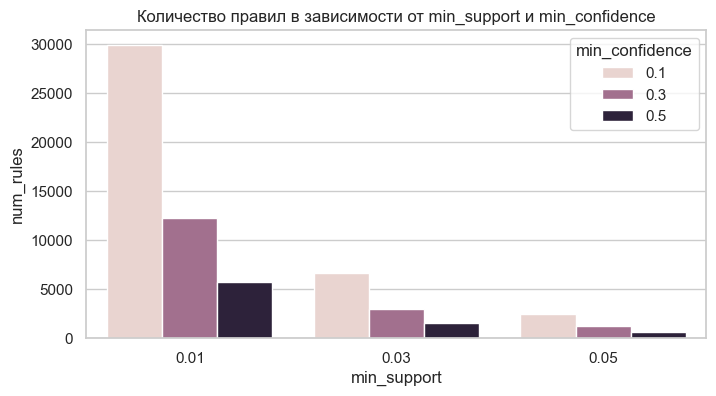

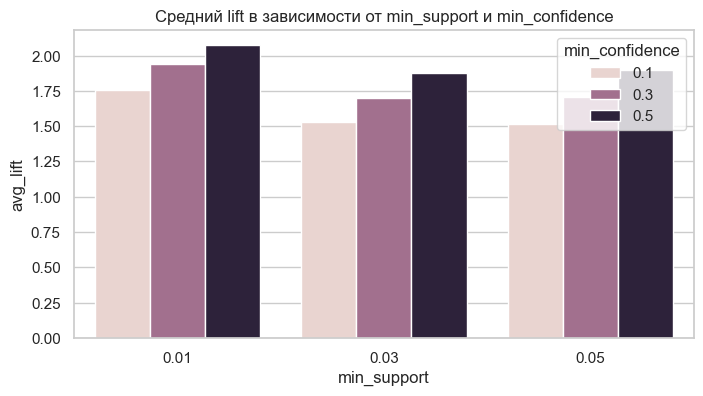

In [ ]:
# Эксперименты с параметрами Apriori

support_values = [0.01, 0.03, 0.05]
conf_values = [0.1, 0.3, 0.5]

results = []

for s in support_values:
    freq = apriori(data_encoded, min_support=s, use_colnames=True)
    for c in conf_values:
        rules_tmp = association_rules(freq, metric="confidence", min_threshold=c)
        if len(rules_tmp) > 0:
            avg_conf = rules_tmp["confidence"].mean()
            avg_lift = rules_tmp["lift"].mean()
        else:
            avg_conf = 0.0
            avg_lift = 0.0
        results.append({
            "min_support": s,
            "min_confidence": c,
            "num_rules": len(rules_tmp),
            "avg_confidence": avg_conf,
            "avg_lift": avg_lift,
        })

results_df = pd.DataFrame(results)
print("Влияние параметров на правила Apriori:")
display(results_df)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=results_df,
    x="min_support",
    y="num_rules",
    hue="min_confidence",
)
plt.title("Количество правил в зависимости от min_support и min_confidence")
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(
    data=results_df,
    x="min_support",
    y="avg_lift",
    hue="min_confidence",
)
plt.title("Средний lift в зависимости от min_support и min_confidence")
plt.show()

### 3.3 Алгоритм FPGrowth

Теперь проведем анализ ассоциативных правил с помощью алгоритма FPGrowth при тех же базовых параметрах поддержки и достоверности и сравним результаты с Apriori.

In [ ]:
# Алгоритм FPGrowth

min_support_fpg = 0.05
min_conf_fpg = 0.3

frequent_itemsets_fpg = fpgrowth(data_encoded, min_support=min_support_fpg, use_colnames=True)
frequent_itemsets_fpg["length"] = frequent_itemsets_fpg["itemsets"].apply(len)

print("Частые наборы элементов (FPGrowth, первые 10):")
display(frequent_itemsets_fpg.sort_values(["support", "length"], ascending=[False, False]).head(10))

rules_fpg = association_rules(frequent_itemsets_fpg, metric="confidence", min_threshold=min_conf_fpg)

rules_fpg["antecedent_len"] = rules_fpg["antecedents"].apply(lambda x: len(x))
rules_fpg["consequent_len"] = rules_fpg["consequents"].apply(lambda x: len(x))

rules_fpg["antecedents_str"] = rules_fpg["antecedents"].apply(lambda x: ", ".join(list(x)))
rules_fpg["consequents_str"] = rules_fpg["consequents"].apply(lambda x: ", ".join(list(x)))

print("\nАссоциативные правила (FPGrowth, первые 10):")
display(rules_fpg[["antecedents_str", "consequents_str", "support", "confidence", "lift"]].head(10))

print("Количество правил (FPGrowth):", len(rules_fpg))

Частые наборы элементов (FPGrowth, первые 10):


,support,itemsets,length
7,0.795217,frozenset({smoker_no}),1
8,0.505232,frozenset({sex_male}),1
0,0.494768,frozenset({sex_female}),1
1,0.428999,frozenset({children_group_children_0}),1
9,0.421525,frozenset({children_group_children_1_2}),1
22,0.408819,"frozenset({sex_female, smoker_no})",2
14,0.402093,frozenset({age_group_age_31_50}),1
145,0.386398,"frozenset({sex_male, smoker_no})",2
24,0.343049,"frozenset({children_group_children_0, smoker_no})",2
146,0.334828,"frozenset({smoker_no, children_group_children_...",2



Ассоциативные правила (FPGrowth, первые 10):


,antecedents_str,consequents_str,support,confidence,lift
0,sex_female,smoker_no,0.408819,0.826284,1.039068
1,smoker_no,sex_female,0.408819,0.514098,1.039068
2,children_group_children_0,sex_female,0.215994,0.503484,1.017616
3,sex_female,children_group_children_0,0.215994,0.436556,1.017616
4,children_group_children_0,smoker_no,0.343049,0.799652,1.005577
5,smoker_no,children_group_children_0,0.343049,0.431391,1.005577
6,children_group_children_0,sex_male,0.213004,0.496516,0.982748
7,sex_male,children_group_children_0,0.213004,0.421598,0.982748
8,"sex_female, children_group_children_0",smoker_no,0.176383,0.816609,1.026901
9,"children_group_children_0, smoker_no",sex_female,0.176383,0.514161,1.039196


Количество правил (FPGrowth): 1259


### 3.4 Минимальные значения поддержки для правил разной длины

Алгоритмически определим минимальные значения поддержки, при которых в выборке появляются частые наборы длины 1, 2 и 3 (и, при наличии, большей длины). Для этого будем постепенно уменьшать `min_support` и отслеживать, при каком значении впервые появляются наборы заданной длины.

In [ ]:
# Поиск минимальных значений поддержки для разных длин наборов

max_k = 3
support_grid = np.linspace(0.25, 0.01, 25)  # от 0.25 до 0.01

min_support_by_k = {k: None for k in range(1, max_k + 1)}

for s in support_grid:
    freq = apriori(data_encoded, min_support=s, use_colnames=True)
    for k in range(1, max_k + 1):
        if min_support_by_k[k] is None:
            has_k = (freq["itemsets"].apply(len) == k).any()
            if has_k:
                min_support_by_k[k] = float(round(s, 4))

min_support_df = pd.DataFrame([
    {"length": k, "min_support": v} for k, v in min_support_by_k.items()
])

print("Минимальные значения поддержки для разных длин наборов (Apriori):")
display(min_support_df)

Минимальные значения поддержки для разных длин наборов (Apriori):


,length,min_support
0,1,0.25
1,2,0.25
2,3,0.22


### 3.5 Визуализация графа ассоциативных правил (Apriori)

Построим сетевой граф на основе части правил Apriori. Узлы будут соответствовать отдельным категориям ("товарам"), а направленные ребра — правилам вида `antecedent → consequent`. Толщина и подписи на ребрах будут отражать значения достоверности и лифта.

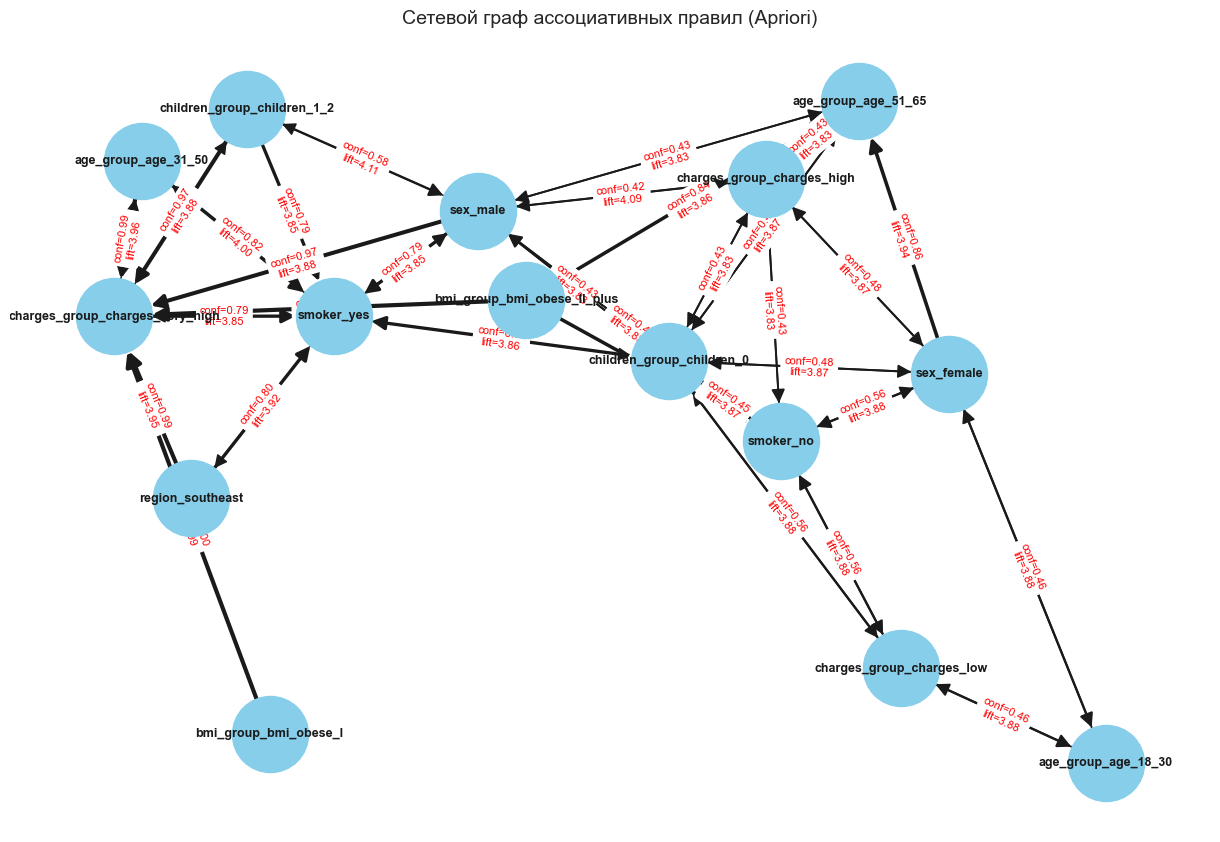

In [ ]:
# Сетевой граф ассоциативных правил (Apriori)

# Возьмем ограниченное количество наиболее интересных правил по лифту
rules_for_graph = rules_apriori.sort_values("lift", ascending=False).head(30).copy()

G = nx.DiGraph()

for _, row in rules_for_graph.iterrows():
    for a in row["antecedents"]:
        for c in row["consequents"]:
            G.add_edge(a, c, weight=row["confidence"], lift=row["lift"])

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=RANDOM_STATE)

edges = G.edges(data=True)
edge_widths = [3 * d["weight"] for (_, _, d) in edges]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="skyblue",
    font_size=9,
    font_weight="bold",
    arrowsize=20,
    width=edge_widths,
)

edge_labels = {(u, v): f"conf={d['weight']:.2f}\nlift={d['lift']:.2f}" for u, v, d in edges}

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="red", font_size=8)

plt.title("Сетевой граф ассоциативных правил (Apriori)", size=14)
plt.axis("off")
plt.show()

### 3.6 Собственный способ визуализации ассоциативных правил

В качестве собственного способа визуализации построим диаграмму рассеяния, где каждая точка соответствует правилу, а:

- ось X — достоверность (`confidence`);
- ось Y — лифт (`lift`);
- цвет — поддержка (`support`);
- размер точки — суммарная длина правила (число элементов в антецеденте и консеквенте).

Такая визуализация позволяет одновременно оценивать силу, значимость и сложность правил.

In [ ]:
# Диаграмма рассеяния для визуализации правил (Apriori)

if len(rules_apriori) > 0:
    rules_vis = rules_apriori.copy()
    rules_vis["rule_len"] = rules_vis["antecedent_len"] + rules_vis["consequent_len"]

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        rules_vis["confidence"],
        rules_vis["lift"],
        c=rules_vis["support"],
        s=50 + 30 * rules_vis["rule_len"],
        cmap="viridis",
        alpha=0.7,
    )
    plt.xlabel("Достоверность (confidence)")
    plt.ylabel("Лифт (lift)")
    plt.title("Визуализация ассоциативных правил (Apriori): confidence vs lift")
    cbar = plt.colorbar(scatter)
    cbar.set_label("Поддержка (support)")
    plt.show()
else:
    print("Правила Apriori не были сгенерированы при текущих параметрах.")

## 4. Заключение

В ходе лабораторной работы были реализованы и исследованы алгоритмы Apriori и FPGrowth на датасете медицинских расходов `Medical Cost Personal Datasets`. Датасет был преобразован в транзакционную форму, где каждому пациенту соответствовала корзина категориальных признаков.

Было показано, как выбор параметров минимальной поддержки и достоверности влияет на количество и качество ассоциативных правил, а также были найдены примеры как содержательных, так и тривиальных правил. Алгоритм FPGrowth дал сопоставимые по качеству результаты с Apriori при меньших вычислительных затратах.

Построенный сетевой граф правил и предложенная визуализация (диаграмма "confidence vs lift" с кодированием поддержки и длины правил) позволили наглядно интерпретировать найденные взаимосвязи между признаками пациентов и оценить их практическую значимость.

## 5. Список источников

1. Dokumentation `mlxtend.frequent_patterns` (Apriori, FPGrowth, association_rules).
2. Kaggle: *Medical Cost Personal Datasets* (`insurance.csv`).
3. Han J., Kamber M., Pei J. *Data Mining: Concepts and Techniques*.
4. Материалы лабораторных работ по курсу "Системы искусственного интеллекта и машинное обучение".

## 6. Приложение

Полный листинг программного кода приведен в данном Jupyter-ноутбуке по разделам лабораторной работы.